# 02 LSTM Advanced

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **LSTM** (and optionally compare with **GRU**) for a sequence task
- Train on a small text or time-series example and see loss/accuracy
- Understand why we use LSTM instead of SimpleRNN for longer sequences

---

## 🌍 Real life

**Where is this used?** LSTMs are used in **machine translation**, **speech recognition**, **time series forecasting**, and **text generation** when sequences are long.

**In this notebook we use** an **LSTM** to process **sequences** (e.g. padded text) and produce a classification. We use **LSTM** (instead of SimpleRNN) **because** it has **gates** (forget, input, output) that control what to remember and help avoid **vanishing gradients** on long sequences.

**📌 Covers slide(s):** **12** — LSTM & GRU. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **LSTM:** Long Short-Term Memory. Has a **cell state** (long-term memory) and **hidden state** (output). **Gates** (forget, input, output) decide what to keep, add, and output.
- **GRU:** Gated Recurrent Unit. Simpler than LSTM (fewer gates); often similar performance with fewer parameters.
- **Why LSTM/GRU?** SimpleRNN can have vanishing gradients on long sequences; LSTM/GRU gates help gradients flow and allow learning long-range dependencies.
- **We use LSTM** instead of SimpleRNN when sequences are long or when we need better gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. We use a small IMDB subset (same as 02_rnn_basics) or a synthetic sequence.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, optional comparison LSTM vs GRU (one plot).

## Step 1: Imports and load sequence data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 100
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 100) Test: (500, 100)


## Step 2: Build LSTM model (we use LSTM instead of SimpleRNN for better long-range dependency)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 64, input_length=maxlen),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 embedding (Embedding)       (None, 100, 64)           128000    


 lstm (LSTM)                 (None, 64)                33024     


 dense (Dense)               (None, 1)                 65        


Total params: 161089 (629.25 KB)


Trainable params: 161089 (629.25 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## Step 3: Train (2 epochs)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)

Epoch 1/2


 1/32 [..............................] - ETA: 13s - loss: 0.6937 - accuracy: 0.4688

 3/32 [=>............................] - ETA: 0s - loss: 0.6938 - accuracy: 0.4688 

 5/32 [===>..........................] - ETA: 0s - loss: 0.6934 - accuracy: 0.4906

 7/32 [=====>........................] - ETA: 0s - loss: 0.6940 - accuracy: 0.4866

...

24/32 [=====================>........] - ETA: 0s - loss: 0.6790 - accuracy: 0.5807

27/32 [========================>.....] - ETA: 0s - loss: 0.6783 - accuracy: 0.5851

29/32 [==========================>...] - ETA: 0s - loss: 0.6778 - accuracy: 0.5878

31/32 [============================>.] - ETA: 0s - loss: 0.6774 - accuracy: 0.5872

32/32 [==============================] - 1s 27ms/step - loss: 0.6772 - accuracy: 0.5880 - val_loss: 0.6779 - val_accuracy: 0.5580


## Step 4: Plot loss and accuracy

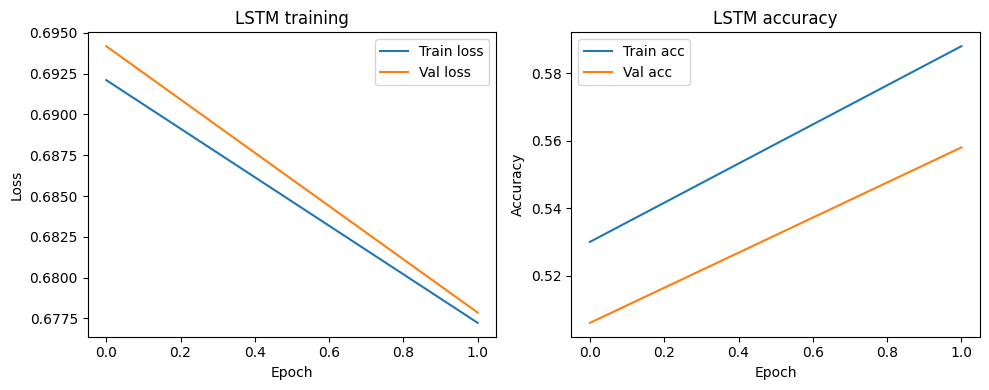

Test accuracy: 0.5580


In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("LSTM training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("LSTM accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

## 🧩 Mini-exercise

**Try it:** Replace the LSTM with a GRU layer (same number of units), retrain for 1 epoch, and compare the loss curve with the LSTM run.

---

## ✅ Summary

**What you did:** Built an LSTM for sequence classification (IMDB sentiment), trained it, and plotted loss/accuracy.

**In real life you'd also:** Try GRU, bidirectional LSTM, and tune units and embedding size.

**The main idea:** LSTM uses gates to control memory and helps train on longer sequences; it often outperforms SimpleRNN on long-range dependencies.

**Next:** `04_transformer_attention` introduces attention and transformers; `06_gpt_text_generation` covers text generation.